
# Практическая работа №2 — метод ломаных (Пиявского)

Цель: реализовать **собственный** метод Пиявского для поиска глобального минимума липшицевой функции на отрезке.

По заданию программа должна:

- принимать функцию одной переменной в виде строки;
- принимать границы отрезка $[a,b]$;
- принимать точность $\varepsilon$;
- находить приближённый глобальный минимум **методом ломаных**, а не перебором мелкой сетки;
- показывать график исходной функции, итоговую ломаную и найденную точку;
- выводить $x_{\min}$, $f(x_{\min})$, число итераций и время;
- быть проверена на функции, у которой на отрезке есть не менее двух локальных минимумов.

Для демонстрации используется одномерная функция Растригина:

$$
f(x)=x^2-10\cos(2\pi x)+10,\qquad x\in[-5.12,5.12].
$$

У неё много локальных минимумов, а глобальный минимум находится в $x=0$, где $f(0)=0$.



## Идея метода

Если функция липшицева с константой $L$, то

$$
|f(u)-f(v)|\le L|u-v|.
$$

Для каждой уже проверенной точки $u_i$ можно построить вспомогательную функцию

$$
g_i(x)=f(u_i)-L|x-u_i|.
$$

Она лежит не выше исходной функции. Максимум всех таких функций

$$
p(x)=\max_i g_i(x)
$$

образует **ломаную-миноранту**.

Метод не ищет минимум исходной функции на мелкой сетке. Вместо этого он:

1. хранит уже вычисленные точки $(u_i,f(u_i))$ — верхние вершины;
2. между соседними верхними вершинами вычисляет точку пересечения двух «галочек»;
3. выбирает самую низкую нижнюю вершину ломаной;
4. именно в её $x$ вычисляет исходную функцию;
5. добавляет новую верхнюю вершину и перестраивает ломаную;
6. останавливается, когда зазор между функцией и ломаной становится меньше $\varepsilon$.

Для соседних точек $(u_l,f_l)$ и $(u_r,f_r)$:

$$
x_{\mathrm{cross}}
=
\frac{f_l-f_r}{2L}
+
\frac{u_l+u_r}{2},
$$

$$
p_{\mathrm{cross}}
=
f_l-L(x_{\mathrm{cross}}-u_l).
$$

Критерий останова:

$$
f(x_{\mathrm{cross}})-p_{\mathrm{cross}}<\varepsilon.
$$


In [ ]:

import time
import numpy as np
import matplotlib.pyplot as plt



## 1. Преобразование строки в функцию

По условию функция приходит строкой. Например:

```text
f(x) = x**2 - 10*cos(2*pi*x) + 10
```

Разрешаем стандартные математические функции NumPy.  
`eval` здесь используется только для учебной задачи; неизвестные внешние строки таким способом исполнять нельзя.


In [ ]:

def make_function(expression: str):
    # Разрешаем запись и с "f(x) =", и без неё.
    expression = expression.strip()

    if "=" in expression:
        expression = expression.split("=", 1)[1].strip()

    # На случай, если степень записали как x^2.
    expression = expression.replace("^", "**")

    allowed = {
        "sin": np.sin,
        "cos": np.cos,
        "tan": np.tan,
        "exp": np.exp,
        "sqrt": np.sqrt,
        "log": np.log,
        "abs": np.abs,
        "pi": np.pi,
        "np": np,
    }

    def f(x):
        return eval(
            expression,
            {"__builtins__": {}},
            {**allowed, "x": x},
        )

    return f



## 2. Оценка константы Липшица

В лекции предлагается:

- если производная известна — взять $L\ge \max |f'(x)|$;
- если производную автоматически получить неудобно — оценить максимальную крутизну по соседним точкам и взять запас.

Здесь сетка используется **только для оценки $L$**.  
Минимум функции по этой сетке не ищется — сам метод дальше работает исключительно через пересечения вспомогательных функций.

Берём запас 10%.


In [ ]:

def estimate_lipschitz(f, a, b, samples=50_001, safety=1.10):
    x = np.linspace(a, b, samples)
    y = np.asarray(f(x), dtype=float)

    # Оценка |Δf / Δx| на соседних точках.
    slopes = np.abs(np.diff(y) / np.diff(x))

    raw_L = float(np.max(slopes))
    L = safety * raw_L

    return L, raw_L



## 3. Нижние вершины ломаной

`points` — уже проверенные точки исходной функции:

$$
(u_i,f(u_i)).
$$

Сначала сортируем их по $x$. Затем для **каждой пары соседних верхних вершин**
вычисляем точку пересечения двух вспомогательных функций.

Получаем список нижних вершин:

$$
(x_{\mathrm{cross}},p_{\mathrm{cross}}).
$$

Из них на каждой итерации выбирается вершина с минимальным $p$.


In [ ]:

def lower_vertices(points, L):
    points = sorted(points, key=lambda point: point[0])
    vertices = []

    for (x_left, f_left), (x_right, f_right) in zip(points[:-1], points[1:]):
        x_cross = (
            (f_left - f_right) / (2 * L)
            + (x_left + x_right) / 2
        )

        # Если L корректна, пересечение должно лежать
        # между соседними проверенными точками.
        if not (x_left - 1e-12 <= x_cross <= x_right + 1e-12):
            raise ValueError(
                "Полученная нижняя вершина вышла за интервал. "
                "Вероятно, константа Липшица L выбрана слишком маленькой."
            )

        p_cross = f_left - L * (x_cross - x_left)

        vertices.append(
            {
                "x": float(x_cross),
                "p": float(p_cross),
                "left": float(x_left),
                "right": float(x_right),
            }
        )

    return vertices



## 4. Основной алгоритм Пиявского

На старте знаем только значения функции на концах:

$$
(a,f(a)),\qquad (b,f(b)).
$$

Дальше на каждой итерации:

1. строим все текущие нижние вершины;
2. выбираем самую низкую;
3. вычисляем исходную функцию только в её $x$;
4. считаем зазор
   $$
   \delta=f(x)-p(x);
   $$
5. новую точку добавляем в список верхних вершин;
6. если $\delta<\varepsilon$, останавливаемся.

Ответом берём лучшую из **реально вычисленных верхних точек**, то есть точку с минимальным значением исходной функции.


In [ ]:

def piyavsky(
    f,
    a,
    b,
    eps,
    L=None,
    max_iter=10_000,
):
    if a >= b:
        raise ValueError("Должно выполняться a < b.")

    if eps <= 0:
        raise ValueError("eps должна быть положительной.")

    # Если L не передана вручную, оцениваем её автоматически.
    if L is None:
        L, raw_L = estimate_lipschitz(f, a, b)
    else:
        raw_L = None

    start_time = time.perf_counter()

    # Верхние вершины: точки, где значение исходной функции уже вычислено.
    points = [
        (float(a), float(f(a))),
        (float(b), float(f(b))),
    ]

    history = []

    for iteration in range(1, max_iter + 1):
        # Строим нижние вершины текущей ломаной.
        lowers = lower_vertices(points, L)

        # Выбираем самую низкую.
        # При равенстве берём левую.
        best_lower = min(
            lowers,
            key=lambda vertex: (vertex["p"], vertex["x"]),
        )

        x_new = best_lower["x"]
        p_new = best_lower["p"]

        # Только здесь делаем новую пробу исходной функции.
        f_new = float(f(x_new))

        # Зазор между исходной функцией и текущей минорантой.
        gap = f_new - p_new

        history.append(
            {
                "iteration": iteration,
                "x": x_new,
                "f": f_new,
                "p": p_new,
                "gap": gap,
                "left": best_lower["left"],
                "right": best_lower["right"],
            }
        )

        # Нижняя вершина после вычисления f(x) становится новой верхней.
        points.append((x_new, f_new))
        points.sort(key=lambda point: point[0])

        # Критерий останова из метода.
        if gap < eps:
            break
    else:
        raise RuntimeError(
            "Достигнут max_iter. "
            "Увеличьте max_iter или проверьте L и eps."
        )

    elapsed = time.perf_counter() - start_time

    # Берём лучшую из реально проверенных точек.
    best_point = min(points, key=lambda point: point[1])

    return {
        "x_min": best_point[0],
        "f_min": best_point[1],
        "iterations": len(history),
        "evaluations": len(points),
        "time": elapsed,
        "L": L,
        "raw_L": raw_L,
        "last_gap": history[-1]["gap"],
        "points": points,
        "history": history,
    }



## 5. Построение итоговой ломаной

Для визуализации:

- график исходной функции рисуем по частой сетке — это **только рисунок**;
- ломаную строим точно из верхних и нижних вершин метода;
- отмечаем все точки, в которых алгоритм реально вычислял функцию;
- отдельно отмечаем найденную лучшую точку.


In [ ]:

def broken_line_points(points, L):
    points = sorted(points, key=lambda point: point[0])
    lowers = lower_vertices(points, L)

    x_broken = [points[0][0]]
    y_broken = [points[0][1]]

    for lower, right_point in zip(lowers, points[1:]):
        x_broken.append(lower["x"])
        y_broken.append(lower["p"])

        x_broken.append(right_point[0])
        y_broken.append(right_point[1])

    return np.array(x_broken), np.array(y_broken)


def plot_result(f, a, b, result):
    # Частая сетка здесь нужна только для красивого изображения f(x).
    x_plot = np.linspace(a, b, 3000)
    y_plot = f(x_plot)

    x_broken, y_broken = broken_line_points(
        result["points"],
        result["L"],
    )

    tested_x = np.array([point[0] for point in result["points"]])
    tested_y = np.array([point[1] for point in result["points"]])

    plt.figure(figsize=(12, 7))

    plt.plot(x_plot, y_plot, label="Исходная функция f(x)")
    plt.plot(x_broken, y_broken, label="Итоговая ломаная p(x)")

    plt.scatter(
        tested_x,
        tested_y,
        s=18,
        label="Выполненные пробы",
    )

    plt.scatter(
        [result["x_min"]],
        [result["f_min"]],
        s=100,
        label="Найденный минимум",
        zorder=5,
    )

    plt.xlabel("x")
    plt.ylabel("f(x)")
    plt.title("Метод Пиявского: глобальная минимизация")
    plt.grid(True)
    plt.legend()
    plt.show()



# Демонстрация на функции Растригина

Используем

$$
f(x)=x^2-10\cos(2\pi x)+10
$$

на отрезке

$$
[-5.12,5.12]
$$

с точностью

$$
\varepsilon=0.01.
$$

У этой функции много локальных минимумов, поэтому она подходит под требование задания.

Для контроля выбора $L$:

$$
f'(x)=2x+20\pi\sin(2\pi x).
$$

Следовательно, на данном отрезке заведомо

$$
|f'(x)|
\le
2\cdot 5.12+20\pi
\approx 73.07.
$$

Автоматическая оценка с запасом должна быть не меньше этого значения или близка к нему с достаточным запасом.


In [ ]:

function_text = "f(x) = x**2 - 10*cos(2*pi*x) + 10"

a = -5.12
b = 5.12
eps = 0.01

f = make_function(function_text)

result = piyavsky(
    f=f,
    a=a,
    b=b,
    eps=eps,
)

analytic_bound = 2 * max(abs(a), abs(b)) + 20 * np.pi

print("Функция:", function_text)
print(f"Отрезок: [{a}, {b}]")
print("eps =", eps)

print("\nОценка L без запаса:", result["raw_L"])
print("Выбранная L с запасом:", result["L"])
print("Аналитическая верхняя оценка для |f'|:", analytic_bound)

print("\nРезультат:")
print("x_min ≈", result["x_min"])
print("f_min ≈", result["f_min"])
print("Итераций:", result["iterations"])
print("Всего вычислений функции:", result["evaluations"])
print("Последний зазор δ:", result["last_gap"])
print("Время, с:", result["time"])


Функция: f(x) = x**2 - 10*cos(2*pi*x) + 10
Отрезок: [-5.12, 5.12]
eps = 0.01

Оценка L без запаса: 71.33264711102461
Выбранная L с запасом: 78.46591182212708
Аналитическая верхняя оценка для |f'|: 73.07185307179586

Результат:
x_min ≈ 0.0
f_min ≈ 0.0
Итераций: 200
Всего вычислений функции: 202
Последний зазор δ: 0.005471840271609775
Время, с: 0.024847270000009303


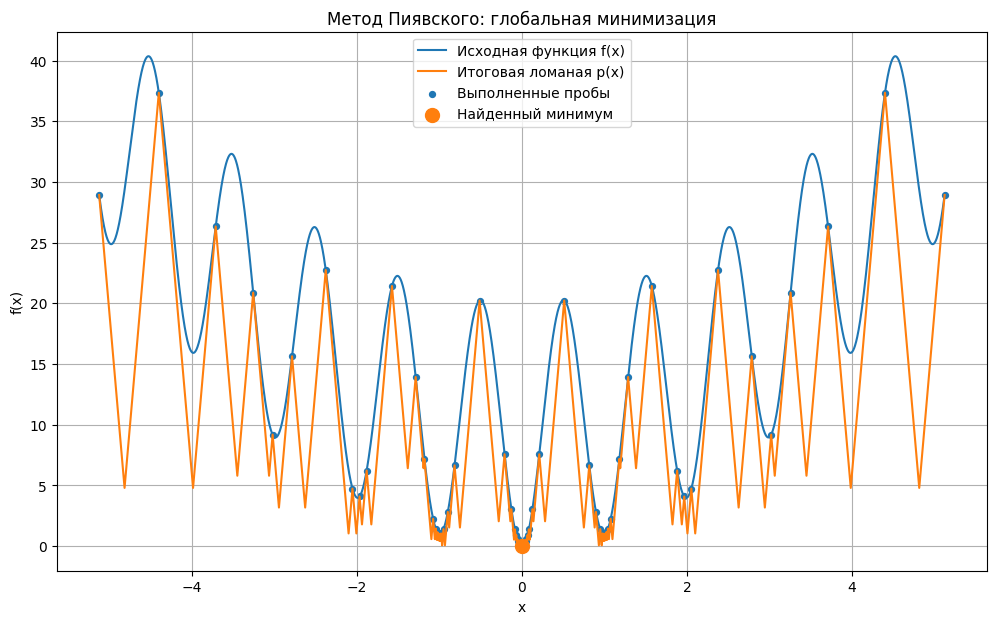

In [ ]:

plot_result(f, a, b, result)



## Последние итерации

Это не требуется для самого алгоритма, но удобно на защите: видно, какую нижнюю вершину выбирали, какое значение функции получили и как уменьшался зазор.


In [ ]:

for row in result["history"][-10:]:
    print(
        f"итерация {row['iteration']:3d}: "
        f"x = {row['x']:.6f}, "
        f"f(x) = {row['f']:.6f}, "
        f"p(x) = {row['p']:.6f}, "
        f"δ = {row['gap']:.6f}"
    )


итерация 191: x = 0.004402, f(x) = 0.003844, p(x) = -0.008129, δ = 0.011973
итерация 192: x = 0.004688, f(x) = 0.004359, p(x) = -0.006065, δ = 0.010424
итерация 193: x = -0.004688, f(x) = 0.004359, p(x) = -0.006065, δ = 0.010424
итерация 194: x = 0.004960, f(x) = 0.004880, p(x) = -0.006065, δ = 0.010945
итерация 195: x = -0.004960, f(x) = 0.004880, p(x) = -0.006065, δ = 0.010945
итерация 196: x = 0.005239, f(x) = 0.005445, p(x) = -0.005499, δ = 0.010944
итерация 197: x = 0.005526, f(x) = 0.006057, p(x) = -0.005499, δ = 0.011556
итерация 198: x = -0.005526, f(x) = 0.006057, p(x) = -0.005499, δ = 0.011556
итерация 199: x = -0.005239, f(x) = 0.005445, p(x) = -0.005499, δ = 0.010944
итерация 200: x = 0.000209, f(x) = 0.000009, p(x) = -0.005463, δ = 0.005472



# Вывод

В работе реализован метод ломаных (метод Пиявского) для глобальной минимизации липшицевой функции на отрезке.

Алгоритм не перебирает весь отрезок для поиска минимального значения. Новая проба функции каждый раз выбирается как самая низкая вершина текущей ломаной-миноранты, вычисленная через пересечение вспомогательных функций.

На функции Растригина метод корректно находит глобальный минимум в окрестности

$$
x^*=0,\qquad f(x^*)=0.
$$

При этом на заданном отрезке присутствует множество локальных минимумов, поэтому пример демонстрирует именно глобальный характер метода.
